## ResNet50 Model Data Processing and Model Training

### Modifications:

The first iteration of the pneumonia model suffered from overfitting. In the second iteration we attempted to freeze the first three layes of ResNet50, while unfreezing the fourth layer and the fc classifier. Partial freezing of pre-trained models can be useful in medical context, where datasets are often limited, pre-trained models can learn low-level features, while focusing on domain/dataset specific high-level features (Luthfiarta et al., 2025).  

* `build_model()` function edited to freeze all layers except the last residual block (layer 4), and the classifier.
* Allowed for Adam optimizer to only work on trainable parameters `torch.optim.Adam([{"params": model.layer4.parameters(),"lr": 1e-5},{"params": model.fc.parameters(), "lr": 1e-4},], weight_decay=1e-4)`

### Import & Install Libraries

In [1]:
import sys
import random
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)


In [2]:
!{sys.executable} -m pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

### Reproducability

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### Outcome Variable: Diagnosis

Diagnoses of interest:

* Pneumonia
* Pneumothorax

In [5]:
# CheXpert labeler contains labels at time of x-rays
chexpert_file = "/nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/mimic-cxr-2.0.0-chexpert.csv.gz"
# MIMIC-CXR official split metadata file that labels each study train/val/test
split_file = "/nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/mimic-cxr-2.0.0-split.csv.gz"


In [6]:
# Convert CheXpert label to dataframe and keep relevant columns
chex_df = pd.read_csv(chexpert_file)
chex_df = chex_df[['subject_id', 'study_id', 'Pneumonia']].copy()

# Keep only definite labels
chex_df = chex_df[chex_df['Pneumonia'].isin([0.0, 1.0])]

chex_df['pneumonia'] = chex_df['Pneumonia'].astype(int)

In [7]:
chex_df.head()

,subject_id,study_id,Pneumonia,pneumonia
7,10000935,50578979,1.0,1
13,10000980,50985099,0.0,0
14,10000980,51967283,1.0,1
15,10000980,54577367,0.0,0
20,10000980,58636672,0.0,0


### Grab the Images

In [8]:
images_path = Path("/nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/files")

In [9]:
records = []

for subject_dir in images_path.glob("p*/*"):  # p10/p10000032
    subject_id = int(subject_dir.name[1:])    # remove leading 'p'
    
    for study_dir in subject_dir.glob("s*"):
        study_id = int(study_dir.name[1:])    # remove leading 's'
        
        for img_file in study_dir.glob("*.jpg"):
            records.append({
                "subject_id": subject_id,
                "study_id": study_id,
                "image_path": str(img_file)
            })

In [10]:
images_df = pd.DataFrame(records)
images_df.head()

,subject_id,study_id,image_path
0,19932024,57682201,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
1,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
2,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
3,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
4,19932024,54345212,/nfs/turbo/si-acastel/mimic-project/data_raw/m...


### Merge Images with CheXpert Labels

In [11]:
# Merge with the CheXpert df
chex_img_df = images_df.merge(
    chex_df[['subject_id', 'study_id', 'pneumonia']],
    on=['subject_id', 'study_id'],
    how='inner'
)

# Apply offical MIMIC-CXR splitting
split_df = pd.read_csv(split_file, usecols=['subject_id', 'study_id', 'split'])
split_df = split_df.drop_duplicates(subset=['subject_id', 'study_id'])

chex_img_df = chex_img_df.merge(
    split_df,
    on=['subject_id', 'study_id'],
    how='inner'
)


In [12]:
print("Total Images:", len(chex_img_df))
print("Prevalence:", chex_img_df['pneumonia'].mean())
print("Split counts:")
print(chex_img_df['split'].value_counts(dropna=False))

Total Images: 69580
Prevalence: 0.37686116700201205
Split counts:
train       68057
test         1028
validate      495
Name: split, dtype: int64


In [13]:
chex_img_df.head()

,subject_id,study_id,image_path,pneumonia,split
0,19932024,54345212,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,validate
1,19932024,50963033,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,validate
2,19932024,58958645,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,validate
3,19056479,58301271,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,train
4,19056479,58301271,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,train


### Subject-wise train/val/test split

In [14]:
# Held-out test set + 5-fold subject-wise CV on non-test data
trainval_df = chex_img_df[chex_img_df['split'] != 'test'].reset_index(drop=True)
test_df = chex_img_df[chex_img_df['split'] == 'test'].reset_index(drop=True)

target_col = "pneumonia"
group_col = "subject_id"
N_SPLITS = 5
RANDOM_STATE = 42

cv_df = trainval_df.copy()
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(sgkf.split(cv_df, y=cv_df[target_col], groups=cv_df[group_col]))

In [15]:
print(f"Train/Val samples: {len(trainval_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Train/Val prevalence: {trainval_df[target_col].mean():.4f}")
print(f"Test prevalence: {test_df[target_col].mean():.4f}")
print(f"Unique Train/Val subjects: {trainval_df[group_col].nunique():,}")
print(f"Unique Test subjects: {test_df[group_col].nunique():,}")
print(f"Folds: {len(fold_splits)}")

Train/Val samples: 68,552
Test samples: 1,028
Train/Val prevalence: 0.3746
Test prevalence: 0.5243
Unique Train/Val subjects: 23,041
Unique Test subjects: 222
Folds: 5


In [16]:
fold_rows = []
for fold, (tr_idx, va_idx) in enumerate(fold_splits, start=1):
    tr = cv_df.iloc[tr_idx]
    va = cv_df.iloc[va_idx]
    fold_rows.append({
        "fold": fold,
        "train_n": len(tr),
        "val_n": len(va),
        "train_prev": tr[target_col].mean(),
        "val_prev": va[target_col].mean(),
        "train_subjects": tr[group_col].nunique(),
        "val_subjects": va[group_col].nunique(),
    })

fold_summary_df = pd.DataFrame(fold_rows)
print(fold_summary_df[["fold", "train_n", "val_n", "train_prev", "val_prev"]].to_string(index=False))

 fold  train_n  val_n  train_prev  val_prev
    1    55026  13526    0.373260  0.380305
    2    54906  13646    0.375733  0.370292
    3    54769  13783    0.372364  0.383734
    4    54736  13816    0.375713  0.370440
    5    54771  13781    0.376184  0.368551


### Confirm No Data Leakage

In [17]:
for fold, (tr_idx, va_idx) in enumerate(fold_splits, start=1):
    train_subjects = set(cv_df.iloc[tr_idx][group_col])
    val_subjects = set(cv_df.iloc[va_idx][group_col])
    assert train_subjects.isdisjoint(val_subjects), f"Leakage detected in fold {fold}"

assert set(trainval_df[group_col]).isdisjoint(set(test_df[group_col])), "Train/Val and test subjects overlap"
print("No subject leakage detected across all folds and held-out test split.")


No subject leakage detected across all folds and held-out test split.


### Preprocessing RadImageNet

In [18]:
# https://huggingface.co/Lab-Rasool/RadImageNet#preprocessing

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Create PyTorch Dataset to be Wrapped Around [DataLoader](https://docs.pytorch.org/docs/stable/data.html)

In [19]:
class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")
        label = float(row['pneumonia'])

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)

### Setup the Model

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last residual block
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)


def make_pos_weight(train_df, label_col=target_col):
    pos = int((train_df[label_col] == 1).sum())
    neg = int((train_df[label_col] == 0).sum())
    value = neg / max(pos, 1)
    return torch.tensor([value], dtype=torch.float32, device=device), value

device: cuda


### Training and Evaluation

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_probs, all_y = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x).squeeze(1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_probs)

    mean_loss = total_loss / len(loader.dataset)

    return {
        "loss": mean_loss,
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "prevalence": float(y_true.mean()),
    }


def evaluate(model, loader, device, criterion=None):
    model.eval()
    all_probs, all_y = [], []
    total_loss = 0.0
    n_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()

            logits = model(x).squeeze(1)

            # Optionally compute loss if a criterion is provided
            if criterion is not None:
                loss = criterion(logits, y)
                total_loss += loss.item() * x.size(0)
                n_samples += x.size(0)

            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            all_y.append(y.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_probs)

    result = {
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "prevalence": float(y_true.mean()),
        "y_true": y_true,
        "y_prob": y_prob,
    }

    if criterion is not None and n_samples > 0:
        result["loss"] = total_loss / n_samples

    return result

### Training Loop & Save Best Model and Metrics

In [22]:
# training loop parameters
BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = True
EPOCHS = 3

In [23]:
history = []
fold_best_metrics = []
oof_rows = []
test_fold_probs = []
test_true = None

test_ds = CXRDataset(test_df, transform=preprocess)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
has_test_set = len(test_ds) > 0

for fold, (tr_idx, va_idx) in enumerate(fold_splits, start=1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    train_df = cv_df.iloc[tr_idx].reset_index(drop=True)
    val_df = cv_df.iloc[va_idx].reset_index(drop=True)

    train_ds = CXRDataset(train_df, transform=preprocess)
    val_ds = CXRDataset(val_df, transform=preprocess)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    model = build_model()
    pos_weight_t, pos_weight_value = make_pos_weight(train_df, label_col=target_col)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)
    
    # Only optimize parameters that actually require gradients
    optimizer = torch.optim.Adam([
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4},
    ], weight_decay=1e-4)

    best_auprc = -1.0
    best_state = None
    best_val_pred = None

    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, device, criterion=criterion)

        history.append({
        "fold": fold,
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auroc": train_metrics["auroc"],
        "train_auprc": train_metrics["auprc"],
        "val_loss": val_metrics["loss"],
        "val_auroc": val_metrics["auroc"],
        "val_auprc": val_metrics["auprc"],
        "pos_weight": pos_weight_value,
        })

        print(
        f"Fold {fold} | Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"train_auroc={train_metrics['auroc']:.4f} | train_auprc={train_metrics['auprc']:.4f} | "
        f"val_auroc={val_metrics['auroc']:.4f} | val_auprc={val_metrics['auprc']:.4f}"
        )

        if val_metrics["auprc"] > best_auprc:
            best_auprc = val_metrics["auprc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_pred = (val_metrics["y_true"], val_metrics["y_prob"])

    if best_state is not None:
        model.load_state_dict(best_state)

    fold_eval = evaluate(model, val_loader, device)
    fold_best_metrics.append({
        "fold": fold,
        "val_auroc": fold_eval["auroc"],
        "val_auprc": fold_eval["auprc"],
        "val_prevalence": fold_eval["prevalence"],
    })

    if best_val_pred is not None:
        y_true_fold, y_prob_fold = best_val_pred
        for yt, yp in zip(y_true_fold, y_prob_fold):
            oof_rows.append({"fold": fold, "y_true": int(yt), "y_prob": float(yp)})

    if has_test_set:
        test_eval = evaluate(model, test_loader, device)
        test_fold_probs.append(test_eval["y_prob"])
        if test_true is None:
            test_true = test_eval["y_true"]
        else:
            assert np.array_equal(test_true, test_eval["y_true"]), "Test label order mismatch across folds"

history_df = pd.DataFrame(history)
fold_metrics_df = pd.DataFrame(fold_best_metrics)
oof_df = pd.DataFrame(oof_rows)

if test_true is not None and len(test_fold_probs) > 0:
    test_prob_mean = np.mean(np.stack(test_fold_probs, axis=0), axis=0)
    test_pred_df = pd.DataFrame({"y_true": test_true.astype(int), "y_prob": test_prob_mean})
else:
    test_pred_df = pd.DataFrame(columns=["y_true", "y_prob"])

history_df.to_csv("resnet50_pneumonia_cv_history_v2.csv", index=False)
fold_metrics_df.to_csv("resnet50_pneumonia_cv_fold_metrics_v2.csv", index=False)
oof_df.to_csv("resnet50_pneumonia_cv_oof_predictions_v2.csv", index=False)
test_pred_df.to_csv("resnet50_pneumonia_cv_test_predictions_v2.csv", index=False)

print("\nSaved:")
print("- resnet50_pneumonia_cv_history_v2.csv")
print("- resnet50_pneumonia_cv_fold_metrics_v2.csv")
print("- resnet50_pneumonia_cv_oof_predictions_v2.csv")
print("- resnet50_pneumonia_cv_test_predictions_v2.csv")


===== Fold 1/5 =====
Fold 1 | Epoch 1/3 | train_loss=0.7931 | val_loss=0.7713 | train_auroc=0.6954 | train_auprc=0.5772 | val_auroc=0.7264 | val_auprc=0.6170
Fold 1 | Epoch 2/3 | train_loss=0.7328 | val_loss=0.7641 | train_auroc=0.7576 | train_auprc=0.6570 | val_auroc=0.7340 | val_auprc=0.6309
Fold 1 | Epoch 3/3 | train_loss=0.6723 | val_loss=0.7867 | train_auroc=0.8056 | train_auprc=0.7174 | val_auroc=0.7263 | val_auprc=0.6260

===== Fold 2/5 =====
Fold 2 | Epoch 1/3 | train_loss=0.7910 | val_loss=0.7644 | train_auroc=0.6945 | train_auprc=0.5761 | val_auroc=0.7221 | val_auprc=0.6122
Fold 2 | Epoch 2/3 | train_loss=0.7318 | val_loss=0.7598 | train_auroc=0.7564 | train_auprc=0.6524 | val_auroc=0.7297 | val_auprc=0.6246
Fold 2 | Epoch 3/3 | train_loss=0.6714 | val_loss=0.7775 | train_auroc=0.8046 | train_auprc=0.7147 | val_auroc=0.7268 | val_auprc=0.6259

===== Fold 3/5 =====
Fold 3 | Epoch 1/3 | train_loss=0.7954 | val_loss=0.7681 | train_auroc=0.6949 | train_auprc=0.5709 | val_auroc=0

### Evaluation on Test Set

In [24]:
print("Fold-level validation metrics:")
print(fold_metrics_df.to_string(index=False))

print("\nCross-validation summary (mean +/- std):")
print(f"AUROC: {fold_metrics_df['val_auroc'].mean():.4f} +/- {fold_metrics_df['val_auroc'].std(ddof=1):.4f}")
print(f"AUPRC: {fold_metrics_df['val_auprc'].mean():.4f} +/- {fold_metrics_df['val_auprc'].std(ddof=1):.4f}")

# Choose threshold from OOF predictions by maximizing F1
if oof_df.empty:
    test_threshold = 0.5
    print("\nOOF predictions are empty; falling back to threshold=0.5")
else:
    y_oof = oof_df["y_true"].to_numpy()
    p_oof = oof_df["y_prob"].to_numpy()

    thresholds = np.linspace(0.05, 0.95, 37)
    f1s = [f1_score(y_oof, (p_oof >= t).astype(int)) for t in thresholds]
    test_threshold = float(thresholds[int(np.argmax(f1s))])

    print(f"\nSelected threshold from OOF (max F1): {test_threshold:.2f}")
    print(f"Best OOF F1: {max(f1s):.4f}")

if test_pred_df.empty:
    print("\nTest prediction dataframe is empty. Confirm test split loading and rerun training.")
else:
    y_test = test_pred_df["y_true"].to_numpy()
    p_test = test_pred_df["y_prob"].to_numpy()
    y_pred = (p_test >= test_threshold).astype(int)

    print("\nEvaluation on Test Set:")
    print("Test prevalence:", y_test.mean())
    print("Test AUROC:", roc_auc_score(y_test, p_test))
    print("Test AUPRC:", average_precision_score(y_test, p_test))
    print("Test precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Test recall:", recall_score(y_test, y_pred, zero_division=0))
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print("Test F1:", f1_score(y_test, y_pred, zero_division=0))


Fold-level validation metrics:
 fold  val_auroc  val_auprc  val_prevalence
    1   0.733982   0.630860        0.380305
    2   0.726765   0.625901        0.370292
    3   0.738794   0.642546        0.383734
    4   0.725420   0.617121        0.370440
    5   0.734943   0.626880        0.368551

Cross-validation summary (mean +/- std):
AUROC: 0.7320 +/- 0.0057
AUPRC: 0.6287 +/- 0.0092

Selected threshold from OOF (max F1): 0.42
Best OOF F1: 0.6116

Evaluation on Test Set:
Test prevalence: 0.52431906614786
Test AUROC: 0.7120889627462809
Test AUPRC: 0.7242678102068362
Test precision: 0.6352765321375187
Test recall: 0.7884972170686456
Test accuracy: 0.6517509727626459
Test F1: 0.7036423841059603


### Plot AUROC and AUPRC

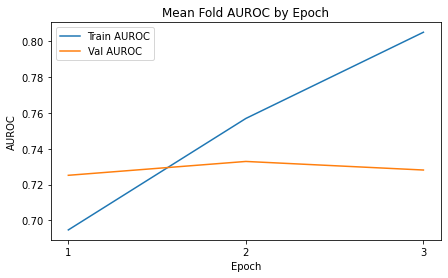

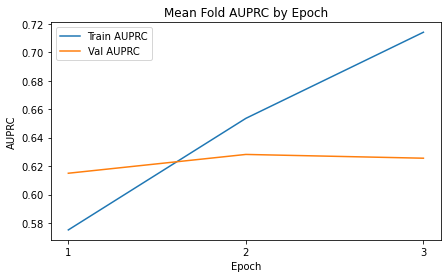

In [25]:
epoch_summary = history_df.groupby("epoch", as_index=False).agg(
    train_auroc=("train_auroc", "mean"),
    val_auroc=("val_auroc", "mean"),
    train_auprc=("train_auprc", "mean"),
    val_auprc=("val_auprc", "mean"),
)

plt.figure(figsize=(7, 4))
plt.plot(epoch_summary["epoch"], epoch_summary["train_auroc"], label="Train AUROC")
plt.plot(epoch_summary["epoch"], epoch_summary["val_auroc"], label="Val AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("Mean Fold AUROC by Epoch")
plt.xticks(epoch_summary["epoch"])
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epoch_summary["epoch"], epoch_summary["train_auprc"], label="Train AUPRC")
plt.plot(epoch_summary["epoch"], epoch_summary["val_auprc"], label="Val AUPRC")
plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title("Mean Fold AUPRC by Epoch")
plt.xticks(epoch_summary["epoch"])
plt.legend()
plt.show()

### Confusion Matrix

Consider choosing a classification threshold for the confusion matrix based on data and business needs. See [Google](https://developers.google.com/machine-learning/crash-course/classification/thresholding) and [Medium](https://medium.com/acorns-data-blog/choosing-the-right-model-threshold-a91bc48f354#9a4f) for more on thresholds.

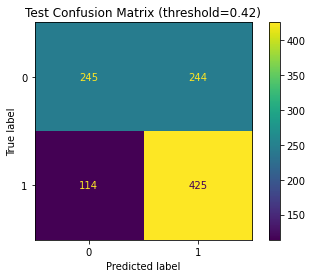

In [26]:
if test_pred_df.empty:
    print("Test prediction dataframe is empty. Confirm test split loading and rerun training.")
else:
    y_test = test_pred_df["y_true"].to_numpy()
    p_test = test_pred_df["y_prob"].to_numpy()
    y_pred = (p_test >= test_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Test Confusion Matrix (threshold={test_threshold:.2f})")
    plt.show()

### References

Luthfiarta, A., Dewi, I. N., Hidayat, E. Y., Supriyanto, C., Putra, P. L. W. E., & Yousif, A. S. (2025). Patch-based histopathological images for non-Hodgkin lymphoma detection using voting CNN with layer freezing. IAENG International Journal of Computer Science, 52(4).